In [1]:
import scanpy as sc
import blend

We import the data, where adata_q represents the dataset with already identified spatial domain labels stored in adata_q.obs['BLEND'].
The dataset adata_k contains a larger collection of cells, including those from adata_q. First, we assign the labels from adata_q to adata_k, storing them in adata_k.obs['cluster'].

In [ ]:
adata_q = sc.read_h5ad('./KNN_cluster_manual/Mouse_embryo_cluster_6w.h5ad')
adata_k = sc.read_h5ad('./KNN_cluster_manual/stereo_seq.PMID_35512705.mouse.embryo.E16.5_GEM_bin14.h5ad')

In [3]:
adata_k.obs['cluster'] = adata_q.obs['BLEND']

In [4]:
adata_k.obs

,raw_x_coord,raw_y_coord,annotation,cluster
6902-15666,6902,15666,Jaw and tooth,NaN
13202-15820,13202,15820,Cavity,NaN
27216-6216,27216,6216,Epidermis,NaN
6202-4928,6202,4928,Brain,NaN
14210-3780,14210,3780,Connective tissue,NaN
...,...,...,...,...
11858-10962,11858,10962,Muscle,NaN
28000-8806,28000,8806,Spinal cord,NaN
24416-6622,24416,6622,Connective tissue,NaN
27524-14280,27524,14280,Bone,NaN


Next, we apply the fill_leiden_by_neighbors function from BLEND. This function uses a KNN-based approach to assign cluster labels to cells in adata_k that do not yet have labels. For example, if adata_k contains 100,000 cells in total, and only 60,000 of them already have assigned labels, the function will distribute labels to the remaining 40,000 unlabeled cells. The entire process takes only a few seconds.

In [5]:
blend.KNN_classify(adata_k, leiden_col='cluster', spatial_key='spatial', K=10)

In [6]:
adata_k.obs

,raw_x_coord,raw_y_coord,annotation,cluster
6902-15666,6902,15666,Jaw and tooth,0
13202-15820,13202,15820,Cavity,NaN
27216-6216,27216,6216,Epidermis,9
6202-4928,6202,4928,Brain,NaN
14210-3780,14210,3780,Connective tissue,NaN
...,...,...,...,...
11858-10962,11858,10962,Muscle,11
28000-8806,28000,8806,Spinal cord,2
24416-6622,24416,6622,Connective tissue,1
27524-14280,27524,14280,Bone,6


In [7]:
adata_k.obs['cluster'].isna().sum()

np.int64(336228)

When running KNN_classify() once, 330,000 cells still remained unassigned to clusters. Running KNN_classify() a second time then resolved these remaining cells. For a dataset with 1.6 million cells, the first round of KNN annotation took 2 minutes, while the second round only required 0.5 minutes. Thus, annotating all 1.6 million cells with cluster labels could be completed in just 3 minutes.

In [8]:
blend.KNN_classify(adata_k, leiden_col='cluster', spatial_key='spatial', K=10)

In [16]:
adata_k.obs

,raw_x_coord,raw_y_coord,annotation,cluster
6902-15666,6902,15666,Jaw and tooth,0
13202-15820,13202,15820,Cavity,3
27216-6216,27216,6216,Epidermis,9
6202-4928,6202,4928,Brain,4
14210-3780,14210,3780,Connective tissue,1
...,...,...,...,...
11858-10962,11858,10962,Muscle,11
28000-8806,28000,8806,Spinal cord,2
24416-6622,24416,6622,Connective tissue,1
27524-14280,27524,14280,Bone,6


In [9]:
adata_k.obs['cluster'].isna().sum()

np.int64(1508)

Finally, the results after label assignment for the full dataset adata_k are visualized.

In [10]:
sc.pp.normalize_total(adata_k, target_sum=1e4)
sc.pp.log1p(adata_k)
sc.pp.highly_variable_genes(adata_k)
adata_k = adata_k[:, adata_k.var.highly_variable]
sc.pp.scale(adata_k, max_value=10)
sc.tl.pca(adata_k, svd_solver='arpack')
sc.pp.neighbors(adata_k, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata_k)

/home/lixuan/miniconda3/envs/blend_demo/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


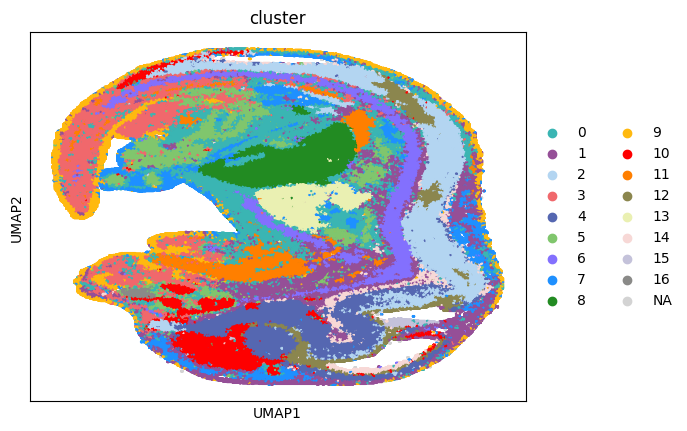

In [15]:
custom_colors = ['#3ab5b3','#954f97','#b3d5f1','#f0686c','#5567b1','#80c66d','#8370fe','#1e90ff','#228b22','#ffb90f','#fe0000','#ff7f00','#8b864e','#eaf0b2','#f7d8d6','#c4c2da','#8a8a88','#d8a266','#b86078',
                 '#39b086',"#3467a1","#345201","#ebe5c2", "#D57358", "#023047", "#F7CA71", "#1697a6", "#8bc6cc", "#C9DEC3","#169820"]
adata_k.obsm['X_umap'] = adata_k.obsm['spatial']
sc.pl.umap(adata_k, color=['cluster'], palette=custom_colors, legend_loc='right margin', size=10)